In [1]:
# Import essential libraries
import os
import numpy as np
import pandas as pd

In [2]:
# Import TensorFlow for building and training machine learning models
import tensorflow as tf

# Import Matplotlib's pyplot module for data visualisation and plotting
import matplotlib.pyplot as plt

# Import Scikit-learn for evaluation metrics such as classification reports
from sklearn.metrics import classification_report

2025-07-05 00:49:46.816709: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-07-05 00:49:46.883398: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1751672986.916537  271624 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1751672986.926201  271624 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1751672986.979417  271624 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [3]:
# Import custom loss functions and evaluation metrics for segmentation tasks
from Components.segmentation_utils import Losses, Metrics

# Import a custom optimiser
from Components.model_optimisers import HnAdam

In [4]:
# Import project-specific constants and path definitions
from Components.definitions import *

# Print key dataset and file paths for verification
print(f"Dataset path: {DATA_ROOT}")
print(f"Meta path: {Paths.metadata_csv}")
print(f"Mass training data path: {Paths.new_mass_train_csv}")
print(f"Mass test data path: {Paths.new_mass_test_csv}")
print(f"Mass train tensor path: {Paths.mass_train_tensor_dir}")
print(f"Mass test tensor path: {Paths.mass_test_tensor_dir}")

Dataset path: /mnt/c/Users/lejam/Desktop/CBIS-DDSM/manifest-1748122768688
Meta path: /mnt/c/Users/lejam/Desktop/CBIS-DDSM/manifest-1748122768688/metadata.csv
Mass training data path: /mnt/c/Users/lejam/Desktop/CBIS-DDSM/manifest-1748122768688/new_mass_case_description_train_set.csv
Mass test data path: /mnt/c/Users/lejam/Desktop/CBIS-DDSM/manifest-1748122768688/new_mass_case_description_test_set.csv
Mass train tensor path: /mnt/c/Users/lejam/Desktop/CBIS-DDSM/manifest-1748122768688/mass_tensor/train
Mass test tensor path: /mnt/c/Users/lejam/Desktop/CBIS-DDSM/manifest-1748122768688/mass_tensor/test


# History

### Load history

In [5]:
# Load the training history from the CSV file
history_df = pd.read_csv(os.path.join(DATA_ROOT, 'history.csv'))

# Display the last row of the dataframe to see the final training metrics
history_df.tail(1)

,accuracy,dice_coef,jaccard_index,loss,val_accuracy,val_dice_coef,val_jaccard_index,val_loss,learning_rate,fold
603,0.999088,0.894574,0.822958,0.057177,0.998386,0.842954,0.7528,0.089101,0.0001,49


In [6]:
# Select and display the rows where the validation Dice coefficient or Jaccard index reached their maximum values
history_df.loc[history_df[['val_dice_coef', 'val_jaccard_index']].idxmax().unique()]

,accuracy,dice_coef,jaccard_index,loss,val_accuracy,val_dice_coef,val_jaccard_index,val_loss,learning_rate,fold
571,0.998867,0.865711,0.780831,0.072768,0.999041,0.90143,0.828036,0.055933,0.0001,47


### Visualise history

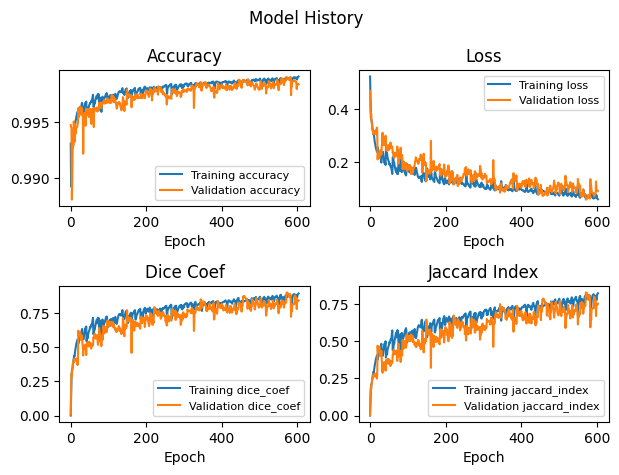

In [7]:
# Visualise the training and validation metrics over epochs using subplots
fig, ax = plt.subplots(2, 2)
fig.suptitle('Model History')
fontsize = 8

# Plot training and validation accuracy
ax[0,0].plot(history_df['accuracy'], label='Training accuracy')
ax[0,0].plot(history_df['val_accuracy'], label='Validation accuracy')
ax[0,0].set_title('Accuracy')
ax[0,0].set_xlabel('Epoch')
ax[0,0].legend(fontsize=fontsize)

# Plot training and validation loss
ax[0,1].plot(history_df['loss'], label='Training loss')
ax[0,1].plot(history_df['val_loss'], label='Validation loss')
ax[0,1].set_title('Loss')
ax[0,1].set_xlabel('Epoch')
ax[0,1].legend(fontsize=fontsize)

# Plot training and validation Dice coefficient
ax[1,0].plot(history_df['dice_coef'], label='Training dice_coef')
ax[1,0].plot(history_df['val_dice_coef'], label='Validation dice_coef')
ax[1,0].set_title('Dice Coef')
ax[1,0].set_xlabel('Epoch')
ax[1,0].legend(fontsize=fontsize)

# Plot training and validation Jaccard index
ax[1,1].plot(history_df['jaccard_index'], label='Training jaccard_index')
ax[1,1].plot(history_df['val_jaccard_index'], label='Validation jaccard_index')
ax[1,1].set_title('Jaccard Index')
ax[1,1].set_xlabel('Epoch')
ax[1,1].legend(fontsize=fontsize)

plt.tight_layout()
plt.show()

# Model

In [8]:
# Load the previously saved model from disk, including any custom loss functions and metrics
loaded_model = tf.keras.models.load_model(
    os.path.join(DATA_ROOT, '8_mass_model.keras'),
    custom_objects={
        'combined_loss': Losses.combined_loss,
        'dice_coef': Metrics.dice_coef,
        'jaccard_index': Metrics.jaccard_index
})

I0000 00:00:1751672991.764977  271624 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5564 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3070 Ti Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


### Model summary

In [9]:
# Display the architecture summary of the loaded model
loaded_model.summary()

Model: "U-Net"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │      1,792 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 128, 128,  │     36,928 │ conv2d[0][0]      │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 64,    │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64, 64,    │          0 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 64, 64,    │     73,856 │ dropout[0][0]     │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 64,    │    147,584 │ conv2d_2[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 32, 32,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 32, 32,    │          0 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 32, 32,    │    295,168 │ dropout_1[0][0]   │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 32, 32,    │    590,080 │ conv2d_4[0][0]    │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 16, 16,    │          0 │ conv2d_5[0][0]    │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 16, 16,    │          0 │ max_pooling2d_2[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 16, 16,    │  1,180,160 │ dropout_2[0][0]   │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 16, 16,    │  2,359,808 │ conv2d_6[0][0]    │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 8, 8, 512) │          0 │ conv2d_7[0][0]    │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 8, 8, 512) │          0 │ max_pooling2d_3[

 Total params: 103,540,037 (394.97 MB)

 Trainable params: 34,513,345 (131.66 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 69,026,692 (263.32 MB)

### Evaluation

In [10]:
# Load the test dataset from saved TensorFlow dataset directory
test_images = tf.data.Dataset.load(Paths.mass_test_tensor_dir)

# Print the shape of one sample image and its mask from the test dataset
for x, y in test_images.take(1):
    print(f"test image shape: {x.shape}, {y.shape}")

# Calculate the total number of test samples
test_rows = len(test_images)

# Define the size of the validation subset (80% of test data)
val_size = int(0.8 * test_rows)

# Calculate the remaining test subset size
test_size = test_rows - val_size

# Define batch size for evaluation
BATCH_SIZE = 8

# Prepare the test batches by skipping validation samples, taking the test subset, and batching them for evaluation
test_batches = (
    test_images
    .skip(val_size)
    .take(test_size)
    .batch(BATCH_SIZE)
)

test image shape: (128, 128, 3), (128, 128, 1)


2025-07-05 00:50:01.107519: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [11]:
# Evaluate the loaded model on the prepared test batches and store the results
evaluations = loaded_model.evaluate(test_batches)

print("Evaluation with test dataset:")
print(f"\tLoss: {evaluations[0]:.4f}")
print(f"\tAccuracy: {evaluations[1] * 100:.2f}%")

I0000 00:00:1751673002.244321  360979 cuda_dnn.cc:529] Loaded cuDNN version 91002


10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 99ms/step - accuracy: 0.9986 - dice_coef: 0.8380 - jaccard_index: 0.7358 - loss: 0.0883
Evaluation with test dataset:
	Loss: 0.0789
	Accuracy: 99.87%


### Prediction

In [12]:
# Generate predictions from the loaded model on the test batches
predictions = loaded_model.predict(test_batches)

# Print the shape of the predictions array
print(f"predictions size: {predictions.shape}")

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step
predictions size: (76, 128, 128, 1)


In [13]:
# Initialise lists to collect all true and predicted pixels
y_true_all = []
y_pred_all = []

# Iterate over batches in the test dataset
for images, masks in test_batches:
    # Predict masks for current batch
    preds = loaded_model.predict(images)  # Shape: (batch, 128, 128, 1)

    # Threshold predictions to get binary masks
    preds = (preds > 0.5).astype(np.uint8)

    # Flatten ground truth masks and predictions, convert to integers, and append to lists
    y_true_all.extend(masks.numpy().flatten().astype(np.uint8))
    y_pred_all.extend(preds.flatten())

# Print detailed classification report with precision, recall, f1-score for each class
print(classification_report(y_true_all, y_pred_all))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 211ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 221ms/step


2025-07-05 00:50:08.544482: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1238900
           1       0.88      0.85      0.86      6284

    accuracy                           1.00   1245184
   macro avg       0.94      0.92      0.93   1245184
weighted avg       1.00      1.00      1.00   1245184



In [14]:
def display(images):
    """
    Display a list of images side-by-side with titles:
    'Input Image', 'Ground Truth', and 'Predicted Mask'.
    """
    plt.figure(figsize=(7, 7))
    title = ["Input Image", "Ground Truth", "Predicted Mask"]
    
    # Loop over each image and plot it in a subplot
    for i in range(len(images)):
        plt.subplot(1, len(images), i+1)
        plt.title(title[i])
        plt.imshow(tf.keras.utils.array_to_img(images[i])) # Convert tensor to image
        plt.axis("off") # Hide axis for clarity
    plt.show()
    
def create_mask(pred_mask):
    """
    Convert a predicted mask tensor into a binary mask.
    If using multi-class masks (argmax), use the first branch (currently disabled).
    Otherwise, threshold the mask at 0.5 to get binary mask.
    
    Also prints unique values, min/max, and shapes for debugging.
    Returns the first mask in the batch.
    """
    # Threshold prediction at 0.5 to get binary mask
    mask = tf.cast(pred_mask > 0.5, tf.uint8)

    # Return the first mask (remove batch dim)
    return mask[0]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step


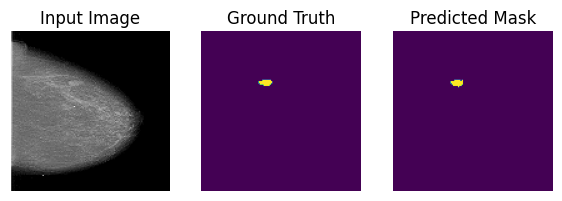

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step


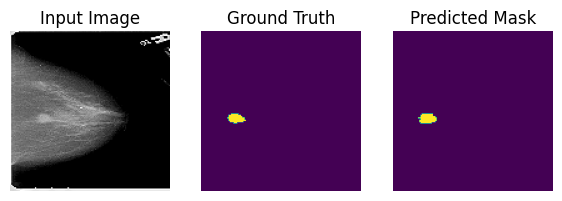

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step


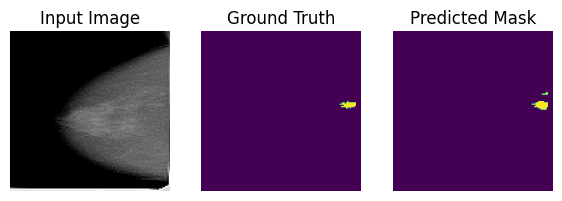

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step


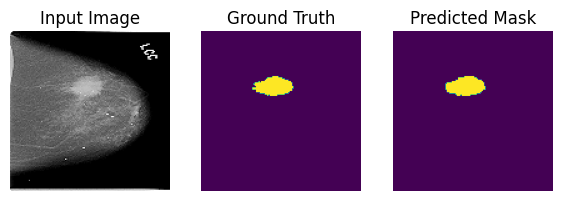

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step


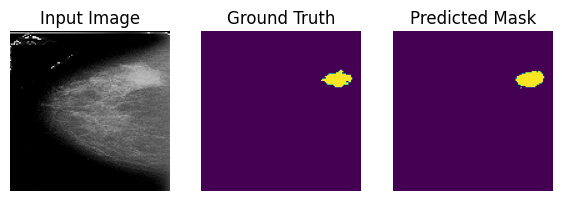

In [15]:
# Number of images/batches to display
image_number = 5

# Iterate through the first 'image_number' batches of test data
for image, mask in test_batches.take(image_number):
    pred_mask = loaded_model.predict(image) # Predict mask for the batch
    true_mask = mask[0] # Take the first mask in the batch (ground truth)

    # Display input image, true mask, and predicted mask side by side
    display([image[0], true_mask, create_mask(pred_mask)])

#for image, mask in test_batches.shuffle(1000).take(image_number):